# CUSTOMER SEGMENTATION - USING DECISION TREE & RANDOM FOREST MODELS 

# Project Overview

This project explores customer segmentation using demographic and behavioural data to better understand the structure of the customer base and identify distinct customer groups.

Using Python and machine learning techniques, the analysis examines how variables such as age, profession, work experience, family size, and spending behaviour relate to different customer segments.

Two classification models — Decision Tree and Random Forest — are implemented to evaluate whether customer attributes can accurately predict segment membership. In addition to model performance, the analysis also focuses on feature importance to identify which variables have the greatest influence on segmentation.

The objective is to demonstrate how data analysis and machine learning can support more targeted marketing strategies and improve customer understanding.

## Import Libraries & Check the data Quality  

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('Customer_Segmentation_dataset.csv')
print(df.info())
# missing Values in following columns: Ever_Married, Graduated, Profession, Work Experience,Family Size, Var_1
# the missing values will be replaced with the median when the variable is numerical and the most frequent value when the the variable 
#is categoricsl 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
 10  Segmentation     2627 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 225.9+ KB
None


## Filling missing values & Encoding Categorical Variables

In [3]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

In [4]:
df[["Work_Experience","Family_Size"]] = num_imputer.fit_transform(
    df[["Work_Experience","Family_Size"]]
)

In [5]:
cat_imputer = SimpleImputer(strategy="most_frequent")

In [6]:
cat_imputer = SimpleImputer(strategy="most_frequent")

df[["Ever_Married","Graduated","Profession","Var_1"]] = cat_imputer.fit_transform(
    df[["Ever_Married","Graduated","Profession","Var_1"]]
)

In [7]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [8]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,458996,Female,Yes,69,No,Artist,0.0,Low,1.0,Cat_6,A
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
4,459001,Female,No,19,No,Marketing,1.0,Low,4.0,Cat_6,A


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2627 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2627 non-null   object 
 5   Profession       2627 non-null   object 
 6   Work_Experience  2627 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2627 non-null   float64
 9   Var_1            2627 non-null   object 
 10  Segmentation     2627 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 225.9+ KB


In [10]:
df= df.drop('ID', axis=1)

In [11]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,Female,Yes,69,No,Artist,0.0,Low,1.0,Cat_6,A
3,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
4,Female,No,19,No,Marketing,1.0,Low,4.0,Cat_6,A


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Segmentation'] = le.fit_transform(df['Segmentation'])

In [13]:
df_encoded = pd.get_dummies(df, columns=[
    'Gender',
    'Ever_Married',
    'Graduated',
    'Profession',
    'Spending_Score',
    'Var_1'
], drop_first=True)

## Decision Tree Model 

In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Segmentation", axis=1)
y = df_encoded["Segmentation"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=6, random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.34      0.43      0.38       177
           1       0.11      0.09      0.10        97
           2       0.37      0.19      0.25       116
           3       0.36      0.43      0.40       136

    accuracy                           0.32       526
   macro avg       0.30      0.29      0.28       526
weighted avg       0.31      0.32      0.30       526



In [18]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy%:", accuracy*100)

Decision Tree Accuracy%: 31.55893536121673


## Importance Features mapping 

In [19]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10)

Age                     0.537871
Work_Experience         0.149922
Gender_Male             0.046571
Family_Size             0.044254
Profession_Executive    0.042383
Var_1_Cat_3             0.023561
Graduated_Yes           0.022989
Var_1_Cat_7             0.020409
Var_1_Cat_5             0.018242
Var_1_Cat_6             0.017907
dtype: float64

In [20]:
importance = pd.Series(model.feature_importances_, index=X.columns)

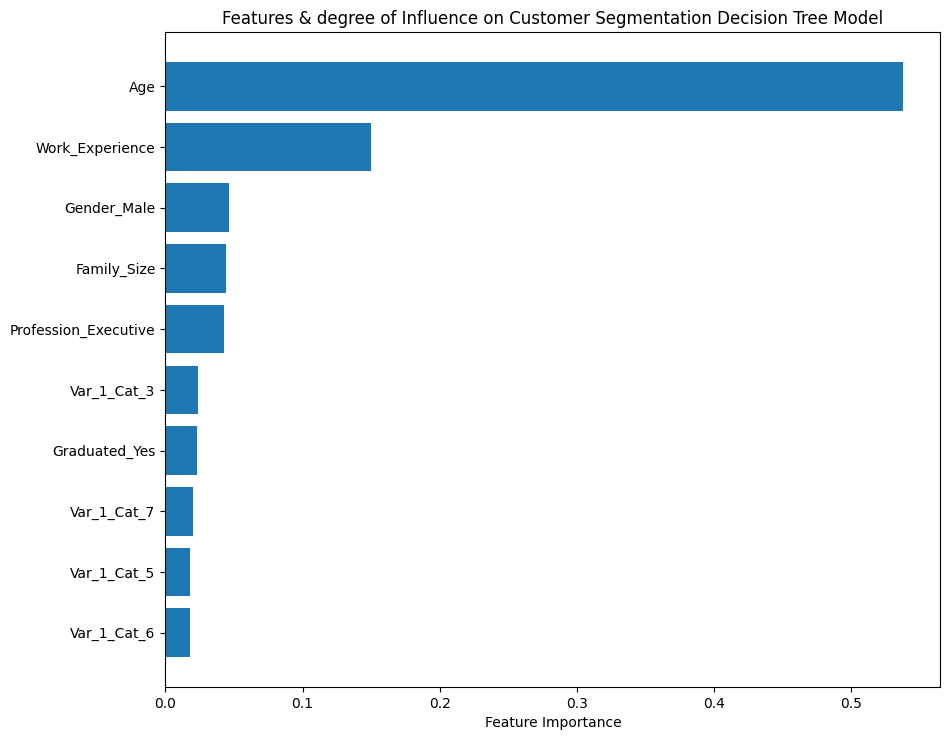

In [21]:
import matplotlib.pyplot as plt

# sort importance
importance_sorted = importance.sort_values(ascending=False)

# take top 10 features
top_features = importance_sorted.head(10)

plt.figure(figsize=(10,8.5))
plt.barh(top_features.index, top_features.values)

plt.xlabel("Feature Importance")
plt.title("Features & degree of Influence on Customer Segmentation Decision Tree Model")

plt.gca().invert_yaxis()

plt.show()

## Decision Tree Map

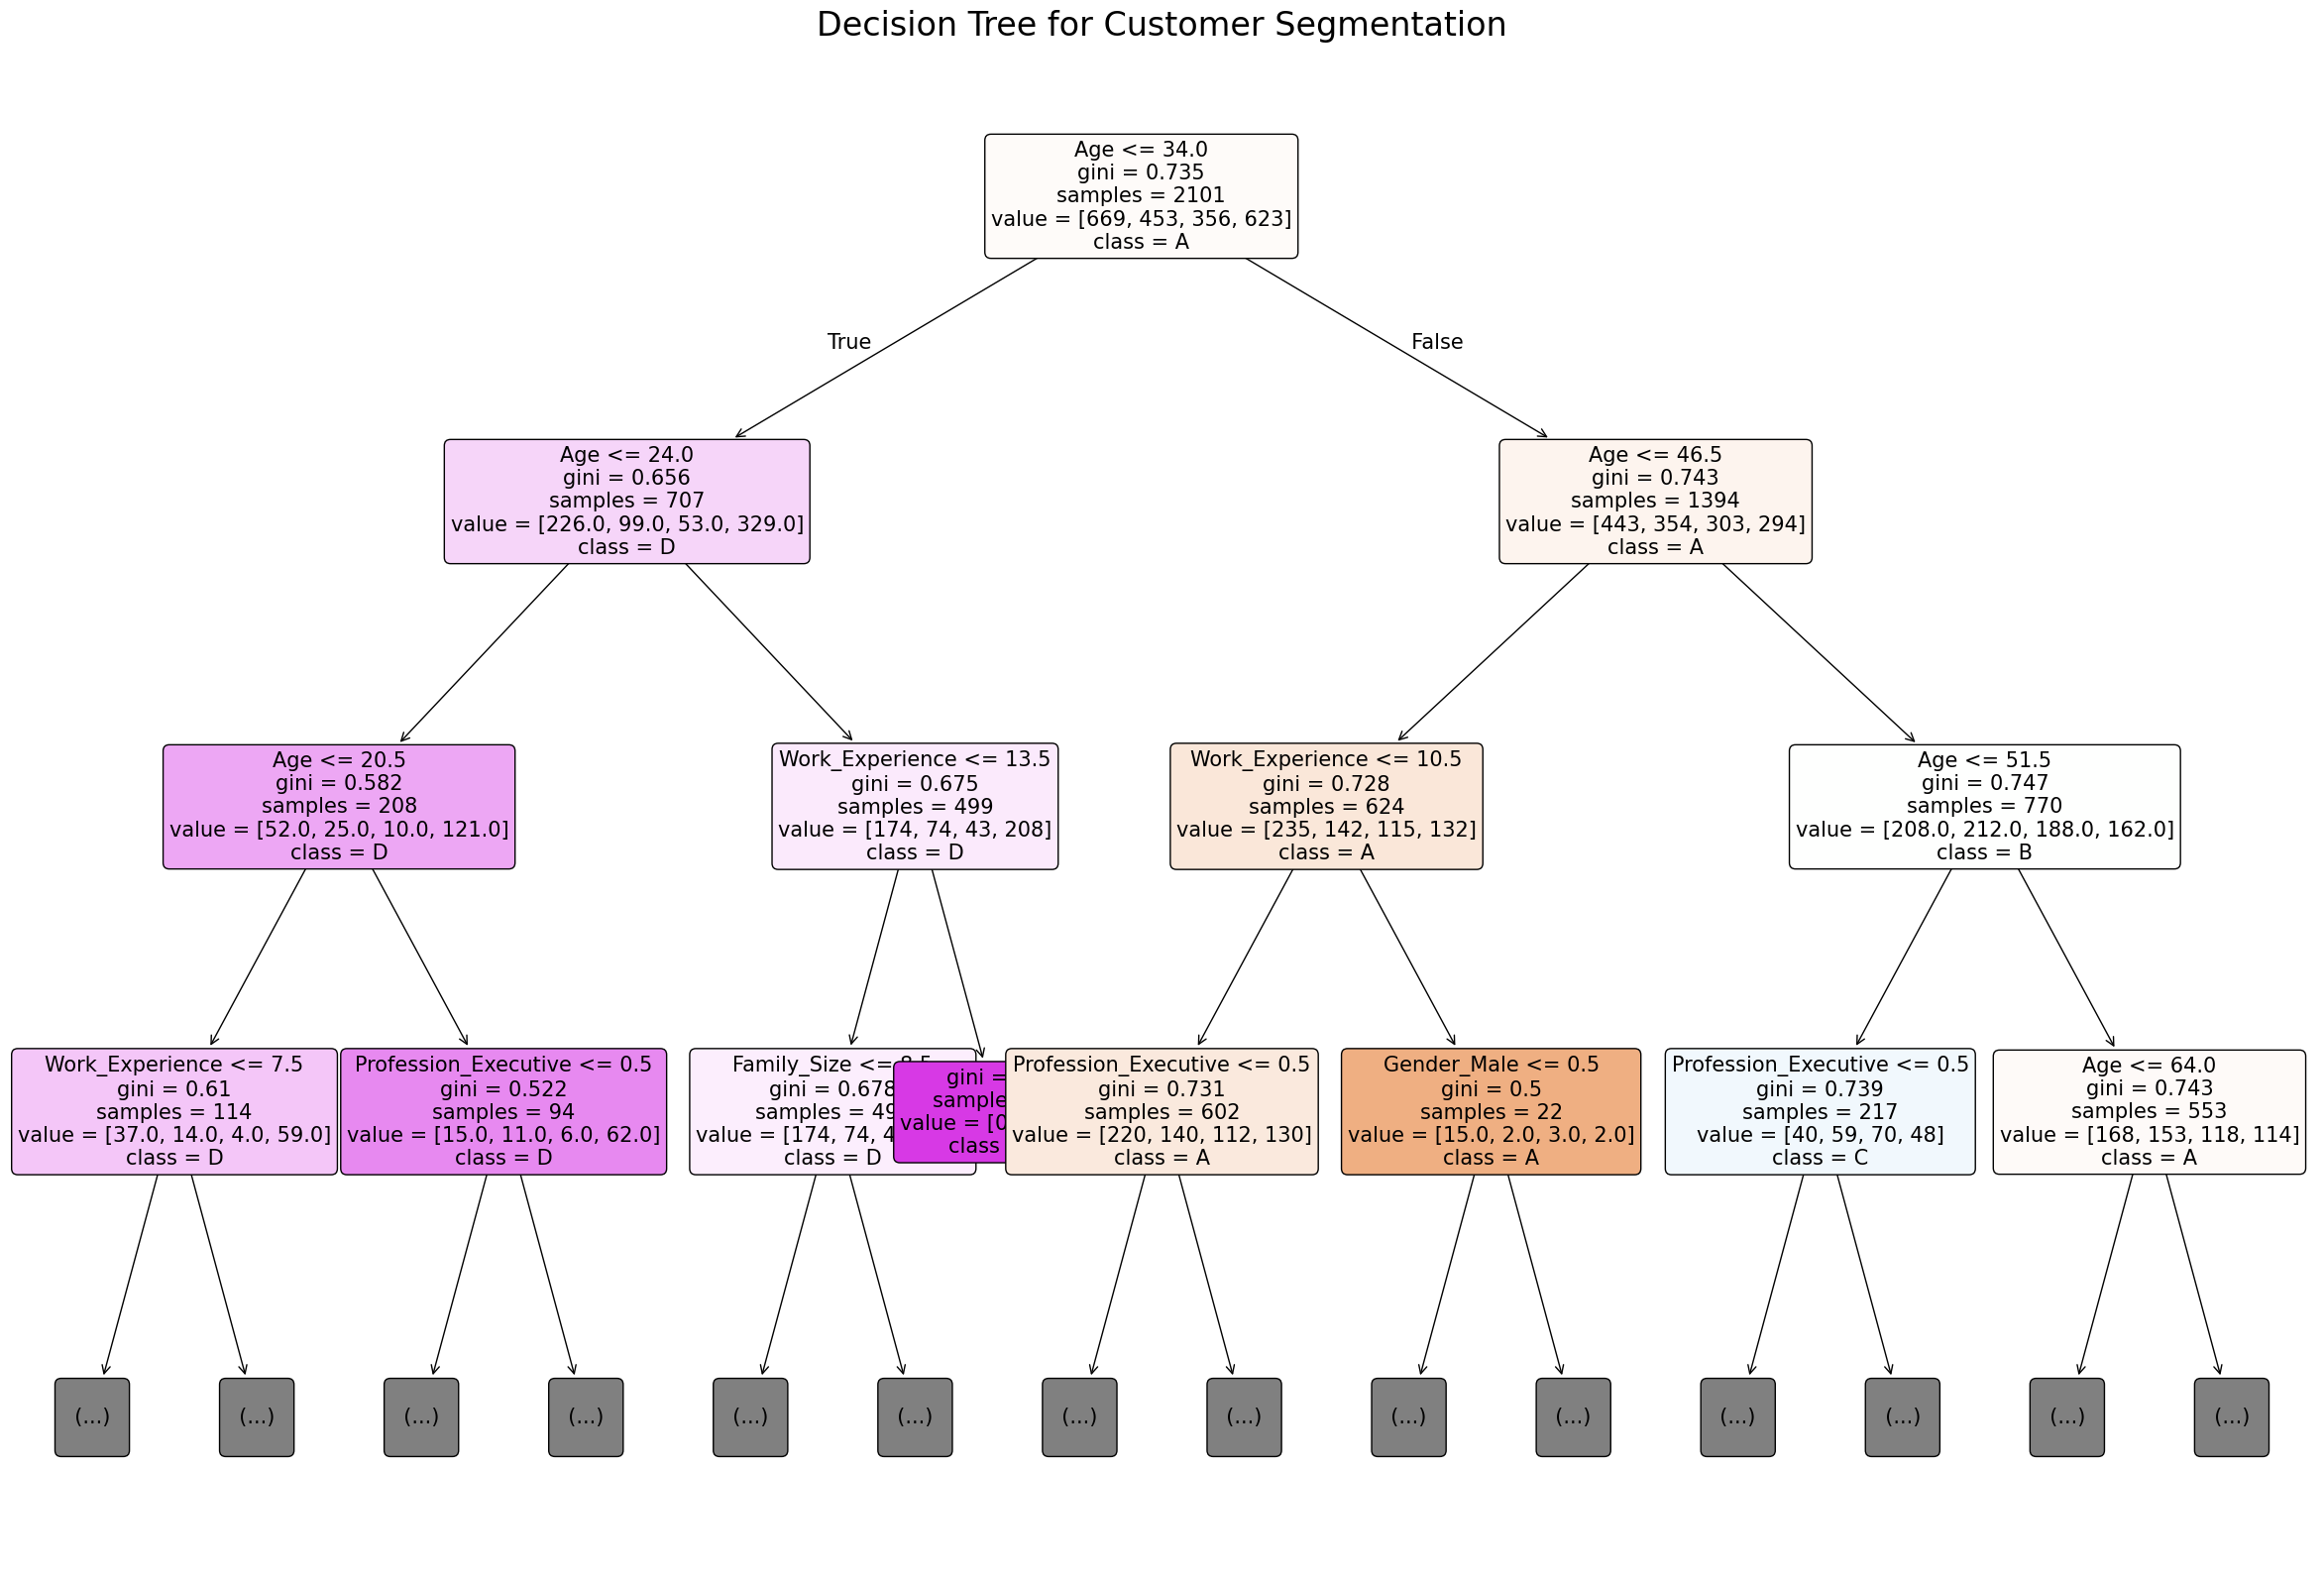

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 20))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['A', 'B', 'C', 'D'],
    filled=True,
    rounded=True,
    fontsize=15,
    max_depth=3
)

plt.title("Decision Tree for Customer Segmentation", fontsize=24)
plt.show()

## Random Forest 

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy%:", accuracy*100)

Random Forest Accuracy%: 27.186311787072242


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.32      0.34      0.33       177
           1       0.17      0.18      0.17        97
           2       0.21      0.12      0.15       116
           3       0.30      0.38      0.34       136

    accuracy                           0.27       526
   macro avg       0.25      0.25      0.25       526
weighted avg       0.26      0.27      0.26       526



In [27]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10)

Age                         0.345949
Work_Experience             0.157700
Family_Size                 0.128964
Gender_Male                 0.048817
Graduated_Yes               0.033792
Var_1_Cat_6                 0.029057
Profession_Entertainment    0.023685
Ever_Married_Yes            0.022627
Profession_Doctor           0.022460
Spending_Score_Low          0.022023
dtype: float64

In [28]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

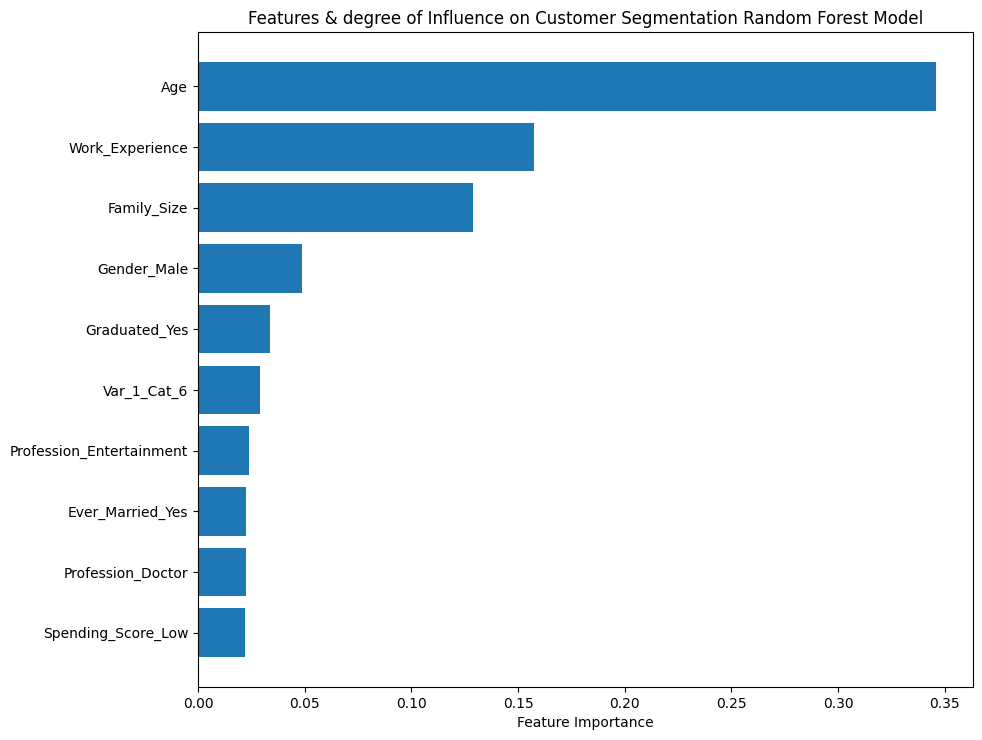

In [29]:
import matplotlib.pyplot as plt

# sort importance
importance_sorted = importance.sort_values(ascending=False)

# take top 10 features
top_features = importance_sorted.head(10)

plt.figure(figsize=(10,8.5))
plt.barh(top_features.index, top_features.values)

plt.xlabel("Feature Importance")
plt.title("Features & degree of Influence on Customer Segmentation Random Forest Model")

plt.gca().invert_yaxis()

plt.show()